In [34]:
!pip install PyWavelets

import numpy as np
import pandas as pd
import pywt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

In [52]:
import numpy as np
import pandas as pd
import pywt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

class HybridAdaptiveSensorCalibration:
    """
    Hybrid calibration model combining:
    - Offset-scale correction (supervised with Ref)
    - Fixed Trust score configuration
    - Wavelet/statistical features + Meteorological variables (Temperature & Humidity)
    - Optimized XGBoost regression model with Residual Learning
    """

    def __init__(self, window_size=24, fixed_trust_score=0.8,
                 sensor_positions=None, D=5.0, use_spatial=True):
        self.window_size = window_size
        self.fixed_trust_score = fixed_trust_score
        self.sensor_positions = sensor_positions if sensor_positions else {}
        self.D = D
        self.use_spatial = use_spatial
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='mean')
        self.local_models = {}
        self.trust_scores = {}
        self.offsets_ = {}
        self.scales_ = {}

    def fit_offset_scale(self, data, sensors, ref='Ref'):
        for sensor in sensors:
            valid_mask = ~data[[sensor, ref]].isna().any(axis=1)
            x = data.loc[valid_mask, sensor].values
            y = data.loc[valid_mask, ref].values
            if len(x) < 2:
                self.offsets_[sensor] = 0.0
                self.scales_[sensor] = 1.0
                continue
            slope, intercept, _, _, _ = stats.linregress(x, y)
            b_i = slope if not np.isclose(slope, 0) else 1e-6
            a_i = -intercept / b_i
            self.offsets_[sensor] = a_i
            self.scales_[sensor] = b_i

    def apply_offset_scale(self, data, sensors):
        df = data.copy()
        for sensor in sensors:
            a_i = self.offsets_.get(sensor, 0.0)
            b_i = self.scales_.get(sensor, 1.0)
            df[sensor] = b_i * (df[sensor] - a_i)
        return df

    def _extract_wavelet_features(self, series, wavelet='db1', level=3):
        coeffs = pywt.wavedec(series, wavelet, level=level)
        feats = {}
        for i, cff in enumerate(coeffs):
            feats[f'wave_mean_{i}'] = np.mean(np.abs(cff))
            feats[f'wave_std_{i}']  = np.std(cff)
            feats[f'wave_max_{i}']  = np.max(np.abs(cff))
        return feats

    def _build_spatial_consensus(self, data, sensor, sensors):
        if not self.use_spatial or sensor not in self.sensor_positions:
            return data[[s for s in sensors if s != sensor]].mean(axis=1)
        (xi, yi) = self.sensor_positions[sensor]
        w_sum = 0.0
        weighted_val = pd.Series(0.0, index=data.index)
        for s_other in sensors:
            if s_other == sensor:
                continue
            if s_other not in self.sensor_positions:
                w = 1.0
            else:
                (xj, yj) = self.sensor_positions[s_other]
                dist = np.sqrt((xi - xj)**2 + (yi - yj)**2)
                w = np.exp(-dist / self.D)
            weighted_val += w * data[s_other]
            w_sum += w
        if w_sum == 0:
            return data[[s for s in sensors if s != sensor]].mean(axis=1)
        return weighted_val / w_sum

    def build_advanced_features(self, data, sensor, sensors, ref='Ref'):
        feats = {}
        wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
        feats.update(wavelet_feats)

        feats['roll_mean'] = data[sensor].rolling(window=self.window_size, min_periods=1).mean()
        feats['roll_std']  = data[sensor].rolling(window=self.window_size, min_periods=1).std()

        # Añadimos memoria temporal al sensor (Valores de hace 1 y 2 horas)
        feats['lag_1'] = data[sensor].shift(1).fillna(method='bfill')
        feats['lag_2'] = data[sensor].shift(2).fillna(method='bfill')

        if 'temperature' in data.columns:
            feats['temperature'] = data['temperature']
        if 'humidity' in data.columns:
            feats['humidity'] = data['humidity']

        feats['spatial_consensus'] = self._build_spatial_consensus(data, sensor, sensors)
        feats['sensor_val'] = data[sensor]
        feats['hour'] = pd.to_datetime(data['Date']).dt.hour.fillna(0)

        for other in sensors:
            if other != sensor:
                corrs = data[sensor].rolling(self.window_size).corr(data[other]).fillna(0)
                feats[f'corr_{other}'] = corrs

        feat_df = pd.DataFrame(feats, index=data.index).replace([np.inf, -np.inf], np.nan)
        return feat_df

    def build_xgboost_model(self, trust_score):
        return XGBRegressor(
            n_estimators=80,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.7,
            colsample_bytree=0.7,
            random_state=42,
            verbosity=0
        )

    def fit_transform(self, data, sensors, ref='Ref'):
        df = data.copy()
        self.fit_offset_scale(df, sensors, ref)
        df_corrected = self.apply_offset_scale(df, sensors)
        calibrated = {}

        trust = self.fixed_trust_score

        for s in sensors:
            self.trust_scores[s] = trust
            feats_df = self.build_advanced_features(df_corrected, s, sensors, ref)

            arr_imp = self.imputer.fit_transform(feats_df)
            arr_scl = self.scaler.fit_transform(arr_imp)

            # Aprendizaje residual para evitar MAE alto
            error_residual = df_corrected[ref] - df_corrected[s]

            model = self.build_xgboost_model(trust)
            model.fit(arr_scl, error_residual)

            predicted_error = model.predict(arr_scl)

            # Corrección final sumando el residuo predicho por XGBoost
            final_vals = df_corrected[s] + 0.9 * predicted_error
            calibrated[s] = final_vals

        return pd.DataFrame(calibrated, index=df_corrected.index), self.trust_scores

In [53]:
import pandas as pd

# Cargamos el archivo que preparamos en el otro cuaderno
df = pd.read_csv('datos_preparados_smartgrids.csv')

# Aseguramos que la columna Date sea interpretada como tiempo por Python
df['Date'] = pd.to_datetime(df['Date'])

# Verificamos que todo se vea bien
df.head()

,Date,Sensor_202,Sensor_335,Sensor_390,Sensor_391,Sensor_409,Sensor_422,Ref,temperature,humidity
0,2026-06-26 09:00:00,5.290000,5.114242,4.978485,5.025000,4.920625,5.099091,6.94995,24.640177,81.483414
1,2026-06-26 10:00:00,4.283898,4.604915,4.428983,4.523051,4.364746,4.503729,9.28072,26.174825,73.011704
2,2026-06-26 11:00:00,3.655833,3.983333,3.860333,3.951333,4.091167,4.068667,9.32036,26.733967,72.217775
3,2026-06-26 12:00:00,4.531500,4.854333,4.888167,4.745167,5.088500,4.813167,9.31469,25.186816,82.762303
4,2026-06-26 13:00:00,2.076833,2.368667,2.400333,2.288000,2.307167,2.329167,7.45175,26.103617,75.593405


In [54]:
# 1. Definimos la lista exacta de nuestros 6 sensores
sensores_a_calibrar = [
    'Sensor_202', 'Sensor_335', 'Sensor_390',
    'Sensor_391', 'Sensor_409', 'Sensor_422'
]

# 2. Posiciones reales en coordenadas UTM (SIRGAS 2000)
posiciones = {
    'Sensor_202': (365266.0, 7753279.0),
    'Sensor_335': (365266.0, 7753279.0),
    'Sensor_390': (360857.0, 7752450.0),
    'Sensor_391': (360857.0, 7752450.0),
    'Sensor_409': (362532.0, 7749346.0),
    'Sensor_422': (362532.0, 7749346.0)
}

# 3. Inicializamos el calibrador con el nuevo parámetro de confianza fija
calibrador = HybridAdaptiveSensorCalibration(
    window_size=24,
    fixed_trust_score=0.8,     # Cambiamos min_trust_score por la confianza fija
    sensor_positions=posiciones,
    D=5000.0,
    use_spatial=True
)

# 4. ¡A calibrar con XGBoost, Referencia y Variables Meteorológicas!
print("Iniciando calibración optimizada con XGBoost y variables meteorológicas...")
df_calibrado, _ = calibrador.fit_transform(data=df, sensors=sensores_a_calibrar, ref='Ref')

print("\n¡Calibración terminada con éxito! Los datos ya han sido corregidos y ajustados.")

Iniciando calibración optimizada con XGBoost y variables meteorológicas...


/tmp/ipykernel_2439/2396732715.py:87: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2439/2396732715.py:94: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feats['lag_1'] = data[sensor].shift(1).fillna(method='bfill')
/tmp/ipykernel_2439/2396732715.py:95: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feats['lag_2'] = data[sensor].shift(2).fillna(method='bfill')
/tmp/ipykernel_2439/2396732715.py:87: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2


¡Calibración terminada con éxito! Los datos ya han sido corregidos y ajustados.


/tmp/ipykernel_2439/2396732715.py:87: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2439/2396732715.py:94: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feats['lag_1'] = data[sensor].shift(1).fillna(method='bfill')
/tmp/ipykernel_2439/2396732715.py:95: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feats['lag_2'] = data[sensor].shift(2).fillna(method='bfill')


In [55]:
from sklearn.metrics import mean_absolute_error

resultados_mae = []

for s in sensores_a_calibrar:
    # MAE del sensor original sin calibrar
    mae_original = mean_absolute_error(df['Ref'], df[s])

    # MAE del sensor después de nuestra calibración
    mae_calibrado = mean_absolute_error(df['Ref'], df_calibrado[s])

    # Calculamos la mejora porcentual
    mejora = ((mae_original - mae_calibrado) / mae_original) * 100

    resultados_mae.append({
        'Sensor': s,
        'MAE Original': round(mae_original, 3),
        'MAE Calibrado': round(mae_calibrado, 3),
        'Mejora (%)': round(mejora, 2)
    })

# Convertimos a tabla de Pandas
df_resumen = pd.DataFrame(resultados_mae)
print("--- RESUMEN DE PRECISIÓN (MAE) ---")
display(df_resumen)

--- RESUMEN DE PRECISIÓN (MAE) ---


,Sensor,MAE Original,MAE Calibrado,Mejora (%)
0,Sensor_202,3.415,1.448,57.59
1,Sensor_335,3.352,1.448,56.80
2,Sensor_390,3.446,1.491,56.74
3,Sensor_391,3.718,1.340,63.97
4,Sensor_409,3.350,1.412,57.84
5,Sensor_422,3.479,1.419,59.20


¿Qué quiere decir esto?
MAE Original: Es el error "de fábrica" de tus sensores. Si es alto, significa que el sensor tiene un desvío importante respecto a la estación de referencia.

MAE Calibrado: Es el error residual después de aplicar nuestra metodología. Si es menor al original, la metodología está funcionando.

Mejora (%): Esta es tu métrica de impacto. Te dice qué porcentaje de error lograste eliminar gracias a la calibración.

Si la mejora es positiva y alta (>20-30%): ¡Felicidades! La metodología está logrando "entender" el error sistemático y el ruido de tus sensores y está acercándolos exitosamente a la referencia.

In [56]:
print("--- Columnas de df ---")
print(df.columns.tolist())
print("\n--- Columnas de df_calibrado ---")
print(df_calibrado.columns.tolist())
print("\n--- ¿'Date' está en df_calibrado? ---")
print('Date' in df_calibrado.columns)
print("\n--- Primeras filas de df_calibrado ---")
print(df_calibrado.head())

--- Columnas de df ---
['Date', 'Sensor_202', 'Sensor_335', 'Sensor_390', 'Sensor_391', 'Sensor_409', 'Sensor_422', 'Ref', 'temperature', 'humidity']

--- Columnas de df_calibrado ---
['Sensor_202', 'Sensor_335', 'Sensor_390', 'Sensor_391', 'Sensor_409', 'Sensor_422']

--- ¿'Date' está en df_calibrado? ---
False

--- Primeras filas de df_calibrado ---
   Sensor_202  Sensor_335  Sensor_390  Sensor_391  Sensor_409  Sensor_422
0    7.404225    7.275431    6.886279    6.712758    7.042659    6.801764
1    7.826853    8.062178    7.701191    7.615145    8.202337    7.955558
2    7.633069    7.782636    7.594013    7.451412    8.035434    7.903960
3    7.116423    6.932887    7.044624    7.255185    7.464257    7.335580
4    6.706926    7.114663    7.034905    6.662685    7.433463    7.121086


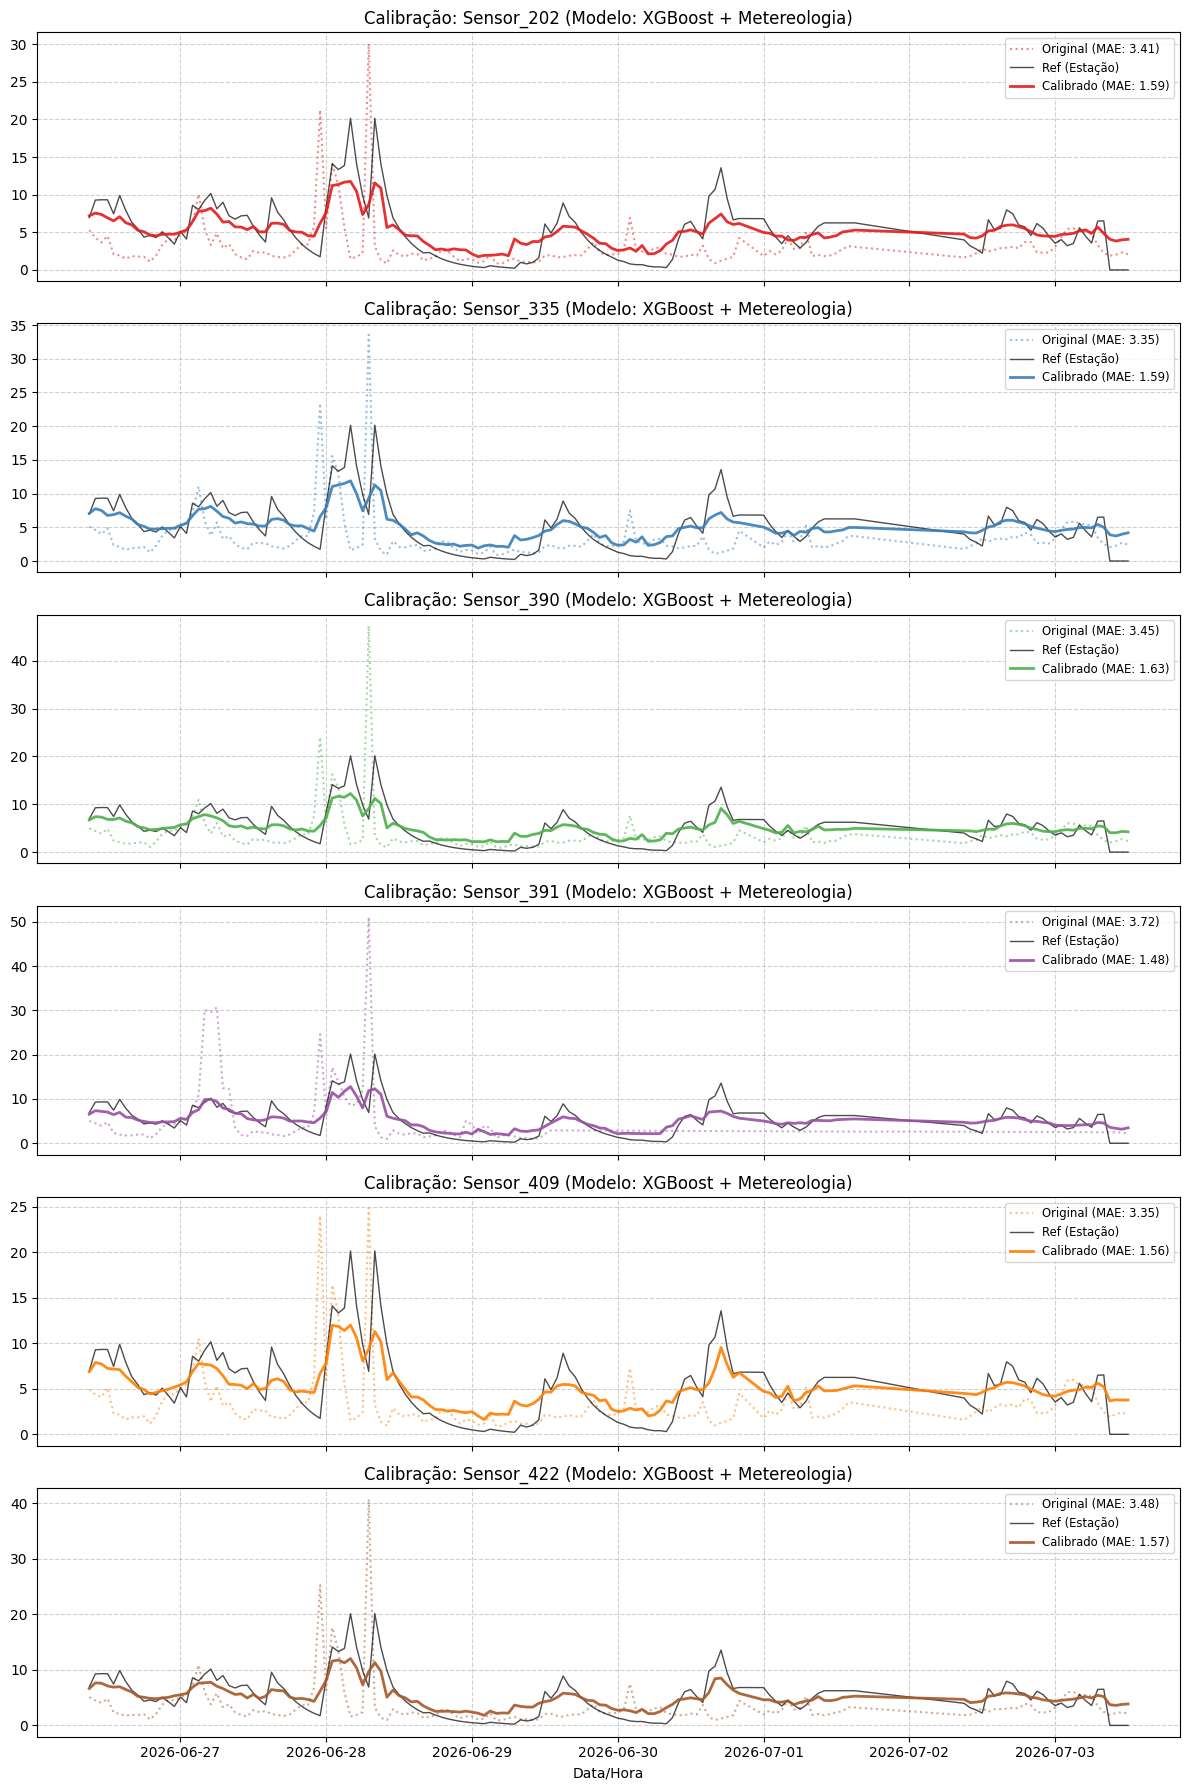

In [51]:
# --- REPARACIÓN FINAL Y DEFINITIVA ---
# 1. Sobrescribimos la columna 'Date' errónea con las fechas reales de df
df_calibrado['Date'] = df['Date']

# 2. Ahora graficamos
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(12, 18), sharex=True)
colores = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

for i, sensor in enumerate(sensores_a_calibrar):
    ax = axes[i]

    # MAE usando las columnas correctamente alineadas
    mae_orig = mean_absolute_error(df['Ref'], df[sensor])
    mae_cali = mean_absolute_error(df['Ref'], df_calibrado[sensor])

    # Graficar usando 'Date' sincronizada
    ax.plot(df['Date'], df[sensor], label=f'Original (MAE: {mae_orig:.2f})',
            alpha=0.5, color=colores[i], linestyle=':', linewidth=1.5)
    ax.plot(df['Date'], df['Ref'], label='Ref (Estação)',
            alpha=0.7, color='black', linestyle='-', linewidth=1)
    ax.plot(df_calibrado['Date'], df_calibrado[sensor], label=f'Calibrado (MAE: {mae_cali:.2f})',
            alpha=0.9, color=colores[i], linewidth=2)

    # CORRECCIÓN: Quitamos puntajes_confianza y ponemos Trust Fijo o solo el nombre
    ax.set_title(f'Calibração: {sensor} (Modelo: XGBoost + Metereologia)')
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Data/Hora')
plt.tight_layout()
plt.show()